In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

In [ ]:
df = pd.read_csv("data_tp_churn.csv")

df.head()

,Periode,Anciennete,Montant_Mensuel,Support_Appels,Contrat,Churn
0,3,6,92.87,1.0,Mensuel,1
1,19,36,98.26,2.0,1 an,0
2,16,41,42.90,0.0,2 ans,0
3,11,53,24.69,2.0,2 ans,0
4,11,41,52.57,1.0,Mensuel,0


We can see the main columns: Period, Tenure, Monthly_Amount, Support_Calls, Contract and Churn.

# **Basic Checks**

**We check:**

Shape of the dataset

Data types

Missing values

In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())

Shape: (5000, 6)

Data Types:
 Periode              int64
Anciennete           int64
Montant_Mensuel    float64
Support_Appels     float64
Contrat             object
Churn                int64
dtype: object

Missing Values:
 Periode              0
Anciennete           0
Montant_Mensuel    670
Support_Appels     493
Contrat              0
Churn                0
dtype: int64


This helps us understand how many rows we have and where missing values exist. Missing values may be important for drift analysis.

Since this is a time-based dataset, we must sort it by Period to avoid temporal leakage.

In [ ]:
df = df.sort_values("Periode")
df["Periode"].describe()

,Periode
count,5000.000000
mean,12.471200
std,6.951952
min,1.000000
25%,6.000000
50%,12.000000
75%,19.000000
max,24.000000


The dataset is now ordered chronologically. This is important because we must train on past data and test on future data.

# Drift-Oriented EDA

**Churn Rate per Period**

We calculate the churn rate for each month to see if the target changes over time.

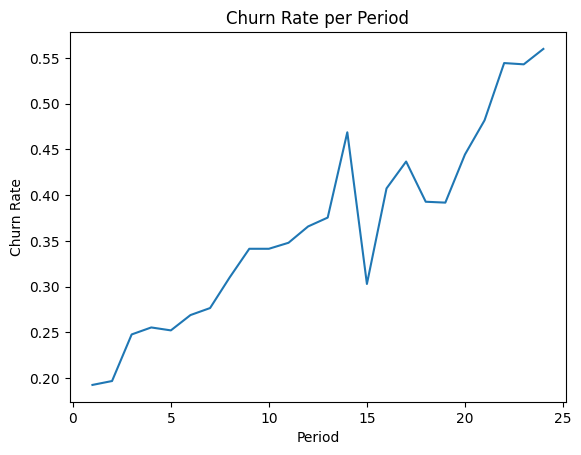

In [ ]:
churn_rate = df.groupby("Periode")["Churn"].mean()

plt.figure()
churn_rate.plot()
plt.title("Churn Rate per Period")
plt.xlabel("Period")
plt.ylabel("Churn Rate")
plt.show()

If the churn rate changes over time, it means the target distribution is drifting. This may reduce model performance if we do not retrain.

**Covariate Drift (Monthly Amount)**

We check if customer spending behavior changes over time.

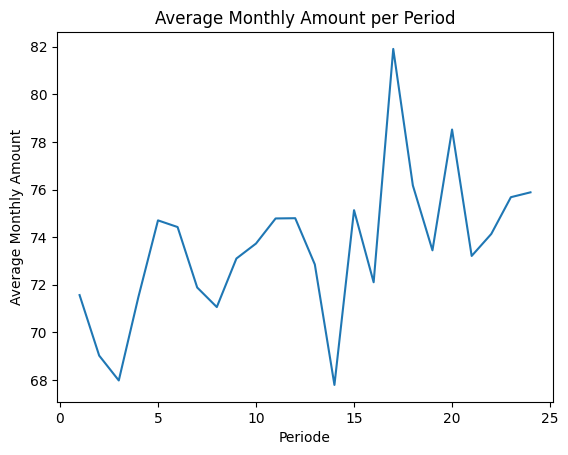

In [ ]:
monthly_mean = df.groupby("Periode")["Montant_Mensuel"].mean()

plt.figure()
monthly_mean.plot()
plt.title("Average Monthly Amount per Period")
plt.xlabel("Periode")
plt.ylabel("Average Monthly Amount")
plt.show()

If the average billed amount changes over time, this indicates covariate drift.

**Distribution Comparison (Early vs Recent)**

We compare early periods with recent periods to visually detect distribution shifts.

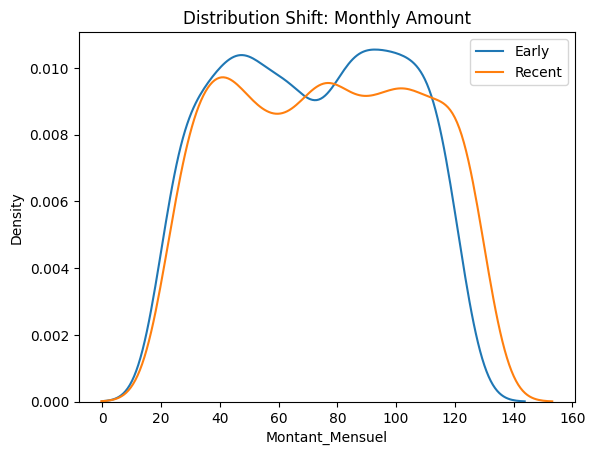

In [ ]:
early = df[df["Periode"] <= df["Periode"].quantile(0.3)]
recent = df[df["Periode"] >= df["Periode"].quantile(0.7)]

plt.figure()
sns.kdeplot(early["Montant_Mensuel"], label="Early")
sns.kdeplot(recent["Montant_Mensuel"], label="Recent")
plt.legend()
plt.title("Distribution Shift: Monthly Amount")
plt.show()

If the two curves are different, it confirms that the data distribution has changed over time.

**Missing Values per Period**

Missing values can also drift. We check if missingness changes over time.

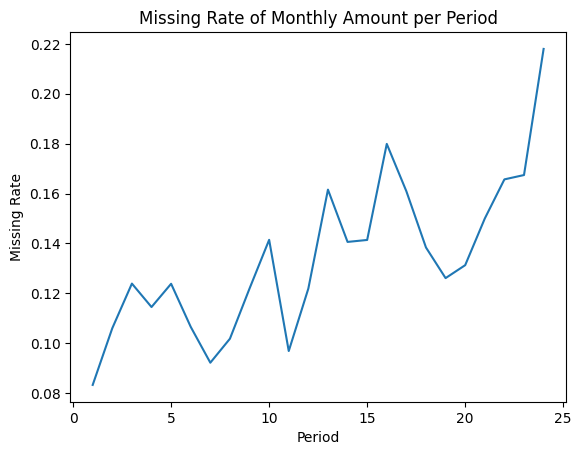

In [ ]:
missing_per_period = df.groupby("Periode")["Montant_Mensuel"].apply(lambda x: x.isna().mean())

plt.figure()
missing_per_period.plot()
plt.title("Missing Rate of Monthly Amount per Period")
plt.xlabel("Period")
plt.ylabel("Missing Rate")
plt.show()

If missing rates change over time, it may indicate data collection changes or business changes.

**Missingness vs Churn**

We check if missing values are related to churn (MNAR case).

In [ ]:
df["Monthly_Missing"] = df["Montant_Mensuel"].isna().astype(int)

missing_churn = df.groupby("Monthly_Missing")["Churn"].mean()
missing_churn

,Churn
Monthly_Missing,
0,0.333949
1,0.556716


If churn rate differs between missing and non-missing groups, missingness is informative and should not be ignored.

# Preprocessing Pipeline (No Leakage)

**Define Features and Target**

We separate features (X) and target (y).

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

**Temporal Train/Test Split**

We split the dataset based on time to avoid temporal leakage.

In [ ]:
# Identify unique sorted periods
periods = sorted(df["Periode"].unique())

# 70% split index
split_index = int(len(periods) * 0.7)

train_periods = periods[:split_index]
test_periods = periods[split_index:]

X_train = X[df["Periode"].isin(train_periods)]
X_test = X[df["Periode"].isin(test_periods)]

y_train = y[df["Periode"].isin(train_periods)]
y_test = y[df["Periode"].isin(test_periods)]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3338, 6)
Test shape: (1662, 6)


The model is trained only on past data and evaluated on future data. This prevents temporal leakage.

**Define Column Types**

We must clearly separate:

Numeric features

Categorical features

**Period should NOT be used as a predictive feature.**

We define numeric and categorical columns for preprocessing.

In [ ]:
numeric_features = ["Anciennete", "Montant_Mensuel", "Support_Appels"]
categorical_features = ["Contrat"]

**Build Preprocessing Pipeline**

We create a ColumnTransformer so preprocessing is learned only on training data.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Full Pipeline with Logistic Regression**

We combine preprocessing and model in one pipeline to avoid leakage.

In [ ]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

**Train the Model**

We fit the model on training data only

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Anciennete',
                                                   'Montant_Mensuel',
                                                   'Support_Appels']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contrat'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Evaluate on Future Data**

Now we test the model on unseen future periods.

We evaluate performance on the test set (future data) using:

AUC → measures ranking quality

Accuracy → percentage of correct predictions

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score

auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)

print("AUC:", auc)
print("Accuracy:", accuracy)

AUC: 0.8480888963746821
Accuracy: 0.7713598074608905


The model is trained on past data and evaluated on future periods.
These metrics represent baseline performance before applying rolling retraining strategies.

# Logistic Regression Baseline
Train, evaluate, and monitor performance drift

We already trained once.
Now we monitor performance over time.

**Rolling Evaluation (Expanding Window)**

Instead of evaluating once on all future data, we evaluate month by month.

For each test period:

Train on all previous periods

Test only on that single period

Store AUC and Accuracy

This allows us to detect performance drift over time.

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

results = []

all_periods = sorted(df["Periode"].unique())

# Start testing after initial training window (70%)
split_index = int(len(all_periods) * 0.7)

for i in range(split_index, len(all_periods)):

    train_periods = all_periods[:i]
    test_period = all_periods[i]

    train_df = df[df["Periode"].isin(train_periods)]
    test_df = df[df["Periode"] == test_period]

    X_train = train_df.drop(columns=["Churn", "Periode"])
    y_train = train_df["Churn"]

    X_test = test_df.drop(columns=["Churn", "Periode"])
    y_test = test_df["Churn"]

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Periode": test_period,
        "AUC": auc,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results)
results_df

,Periode,AUC,Accuracy
0,17,0.843381,0.775862
1,18,0.849181,0.758929
2,19,0.835419,0.743243
3,20,0.845971,0.747475
4,21,0.889854,0.818182
5,22,0.834345,0.757396
6,23,0.836716,0.778281
7,24,0.853480,0.756410


**Plot Performance Over Time**

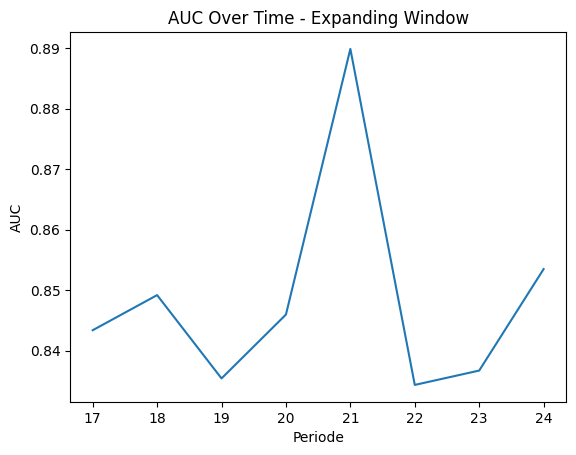

In [ ]:
plt.figure()
plt.plot(results_df["Periode"], results_df["AUC"])
plt.title("AUC Over Time - Expanding Window")
plt.xlabel("Periode")
plt.ylabel("AUC")
plt.show()

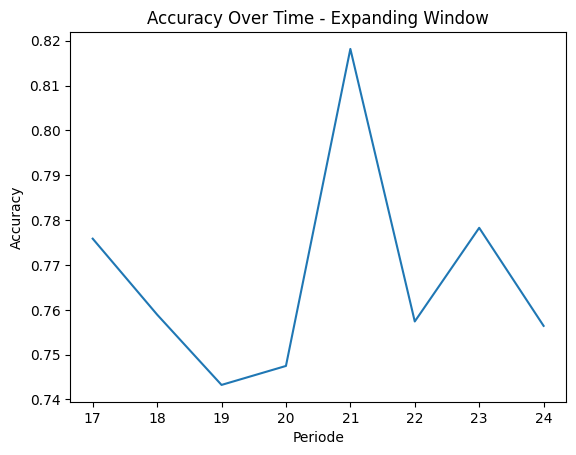

In [ ]:
plt.figure()
plt.plot(results_df["Periode"], results_df["Accuracy"])
plt.title("Accuracy Over Time - Expanding Window")
plt.xlabel("Periode")
plt.ylabel("Accuracy")
plt.show()

We observe how model performance evolves over time.
If AUC decreases in later periods, this suggests performance drift caused by data drift.

# Retraining Policies
**Compare Fixed vs Rolling**

We now compare:

Fixed strategy → Train once on initial window

Rolling strategy → Retrain every month


**Fixed Strategy**

We train once on early data and never retrain.

In [ ]:
fixed_train_periods = all_periods[:split_index]

train_df = df[df["Periode"].isin(fixed_train_periods)]
X_train_fixed = train_df.drop(columns=["Churn", "Periode"])
y_train_fixed = train_df["Churn"]

model.fit(X_train_fixed, y_train_fixed)

fixed_results = []

for period in all_periods[split_index:]:

    test_df = df[df["Periode"] == period]
    X_test = test_df.drop(columns=["Churn", "Periode"])
    y_test = test_df["Churn"]

    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    fixed_results.append({"Periode": period, "AUC": auc})

fixed_df = pd.DataFrame(fixed_results)

**Compare Fixed vs Expanding**

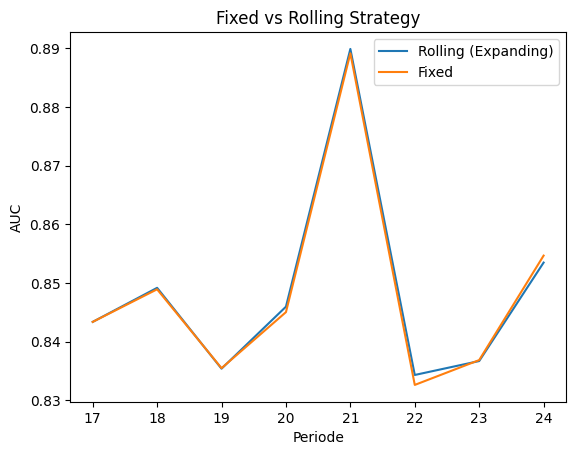

In [ ]:
plt.figure()
plt.plot(results_df["Periode"], results_df["AUC"], label="Rolling (Expanding)")
plt.plot(fixed_df["Periode"], fixed_df["AUC"], label="Fixed")
plt.legend()
plt.title("Fixed vs Rolling Strategy")
plt.xlabel("Periode")
plt.ylabel("AUC")
plt.show()

If rolling performs better in later periods, this confirms that retraining helps adapt to drift.

# Automatic Window Selection
**Backtesting History Length**

Now we test different rolling window sizes.

**Try Different Window Sizes**

In [ ]:
window_sizes = [3, 6, 9, 12]
window_results = []

for window in window_sizes:

    auc_scores = []

    for i in range(window, len(all_periods)):

        train_periods = all_periods[i-window:i]
        test_period = all_periods[i]

        train_df = df[df["Periode"].isin(train_periods)]
        test_df = df[df["Periode"] == test_period]

        X_train = train_df.drop(columns=["Churn", "Periode"])
        y_train = train_df["Churn"]

        X_test = test_df.drop(columns=["Churn", "Periode"])
        y_test = test_df["Churn"]

        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]

        auc_scores.append(roc_auc_score(y_test, y_proba))

    window_results.append({
        "Window": window,
        "Mean_AUC": np.mean(auc_scores)
    })

window_df = pd.DataFrame(window_results)
window_df

,Window,Mean_AUC
0,3,0.870717
1,6,0.866680
2,9,0.863866
3,12,0.858958


**Plot Window Selection**

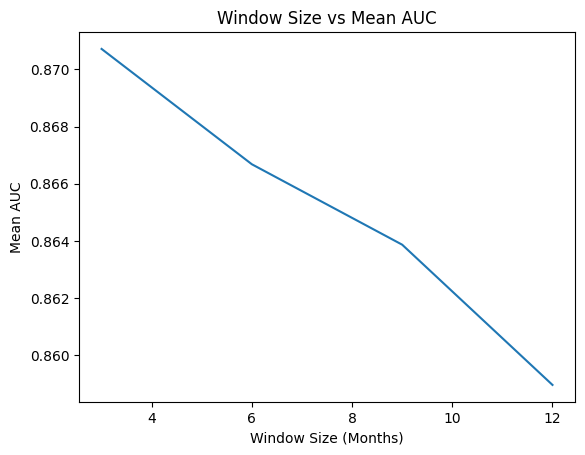

In [ ]:
plt.figure()
plt.plot(window_df["Window"], window_df["Mean_AUC"])
plt.title("Window Size vs Mean AUC")
plt.xlabel("Window Size (Months)")
plt.ylabel("Mean AUC")
plt.show()

The optimal window size balances stability and adaptability.
Smaller windows adapt faster but may be unstable.
Larger windows are stable but less reactive to drift.

# Random Forest
**Compare Nonlinear vs Baseline**

**Build Random Forest Pipeline**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

**Evaluate with Expanding Window**

In [ ]:
rf_results = []

for i in range(split_index, len(all_periods)):

    train_periods = all_periods[:i]
    test_period = all_periods[i]

    train_df = df[df["Periode"].isin(train_periods)]
    test_df = df[df["Periode"] == test_period]

    X_train = train_df.drop(columns=["Churn", "Periode"])
    y_train = train_df["Churn"]

    X_test = test_df.drop(columns=["Churn", "Periode"])
    y_test = test_df["Churn"]

    rf_model.fit(X_train, y_train)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    rf_results.append({"Periode": test_period, "AUC": auc})

rf_df = pd.DataFrame(rf_results)

**Compare Models**

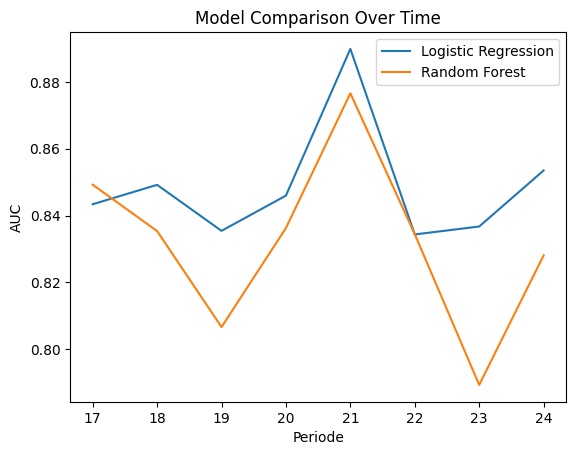

In [ ]:
plt.figure()
plt.plot(results_df["Periode"], results_df["AUC"], label="Logistic Regression")
plt.plot(rf_df["Periode"], rf_df["AUC"], label="Random Forest")
plt.legend()
plt.title("Model Comparison Over Time")
plt.xlabel("Periode")
plt.ylabel("AUC")
plt.show()

**Interpretation**

Random Forest may capture nonlinear patterns better, but it can also be more sensitive to drift.

# Business Optimization
**Cost-Sensitive Threshold Tuning**

# Define Business Costs

Assume:

False Negative cost = 10

False Positive cost = 2

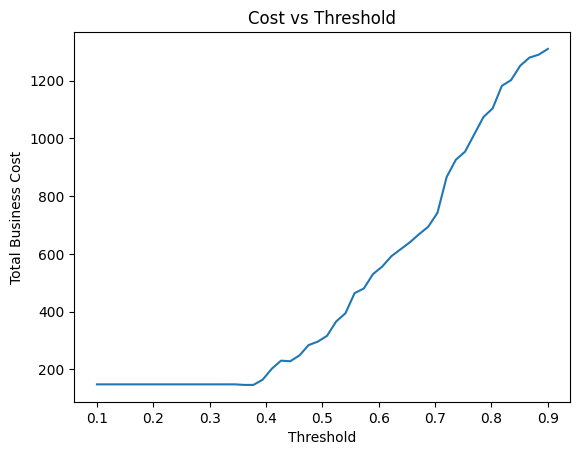

In [ ]:
from sklearn.metrics import confusion_matrix

cost_fn = 10
cost_fp = 2

thresholds = np.linspace(0.1, 0.9, 50)
costs = []

# Use last test period
last_test = df[df["Periode"] == all_periods[-1]]
X_last = last_test.drop(columns=["Churn", "Periode"])
y_last = last_test["Churn"]

model.fit(X_train_fixed, y_train_fixed)
y_proba = model.predict_proba(X_last)[:, 1]

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_last, y_pred).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    costs.append(total_cost)

plt.figure()
plt.plot(thresholds, costs)
plt.title("Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.show()

**Interpretation**

The optimal threshold minimizes total business cost.
It is often different from the default 0.5 threshold.

